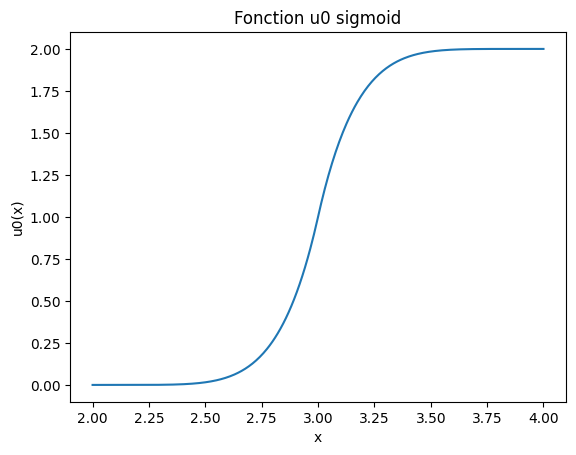

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  

def u0sigmoid(x):
    return np.where(
        x < 2, 0, np.where(
            x < 3, (x - 2)**6, np.where(
                x < 4, 2 - (x - 4)**6, 2
            )
        )
    )

Ldown = 2
Lup = 4
Nx = 500 

x = np.linspace(Ldown, Lup, Nx)
y = u0sigmoid(x)

plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("u0(x)")
plt.title("Fonction u0 sigmoid")
plt.show()

In [4]:
#u_4jm1 = np.roll(u_4[n], 1)  # Décalage de 1 pour u[j-1]
def SchemaUpwind(c,tmax,L,u0,M,N):
    U = np.zeros((M+1,N+1))
    T = np.linspace(0,tmax,N+1)
    X = np.linspace(0,L,M+1)
    DeltaT = tmax/N
    DeltaX = L/M
    r = c*DeltaT/DeltaX
    u = u0(X)
    U[:,0]=u
    print('CFL condition =', np.abs(c)*DeltaT/DeltaX)
    if c>0:
        for i in range (N):
            u[0] = u0(-c*i*DeltaT)
            u[1:] = (1-r)*u[1:] + r*u[0:-1]
            U[:,i+1]=u
    elif c<0:
        for i in range (N):
            u[M] = u0(L-c*i*DeltaT)
            u[:M] = (1+r)*u[:M] - r*u[1:]
            U[:,i+1]=u
    return T, X, U


CFL condition = 0.5


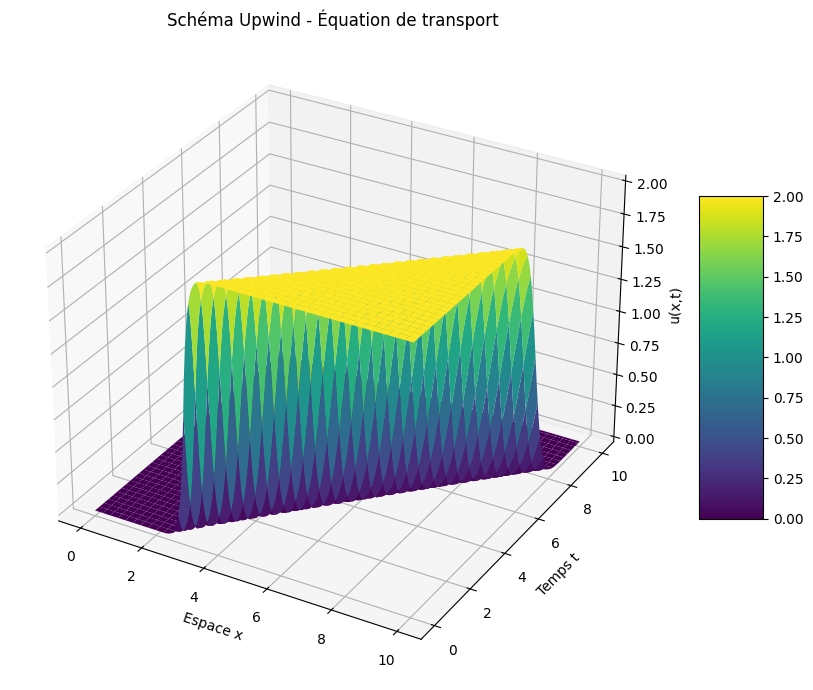

In [5]:
T, X, solution = SchemaUpwind(1,10,10,u0sigmoid,200,400)


TT, XX = np.meshgrid(T, X)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(XX, TT, solution, cmap='viridis')

ax.set_xlabel('Espace x')
ax.set_ylabel('Temps t')
ax.set_zlabel('u(x,t)')
ax.set_title('Schéma Upwind - Équation de transport')
fig.colorbar(surf, shrink=0.5, aspect=5)

plt.tight_layout()
plt.show()

CFL condition = 0.5


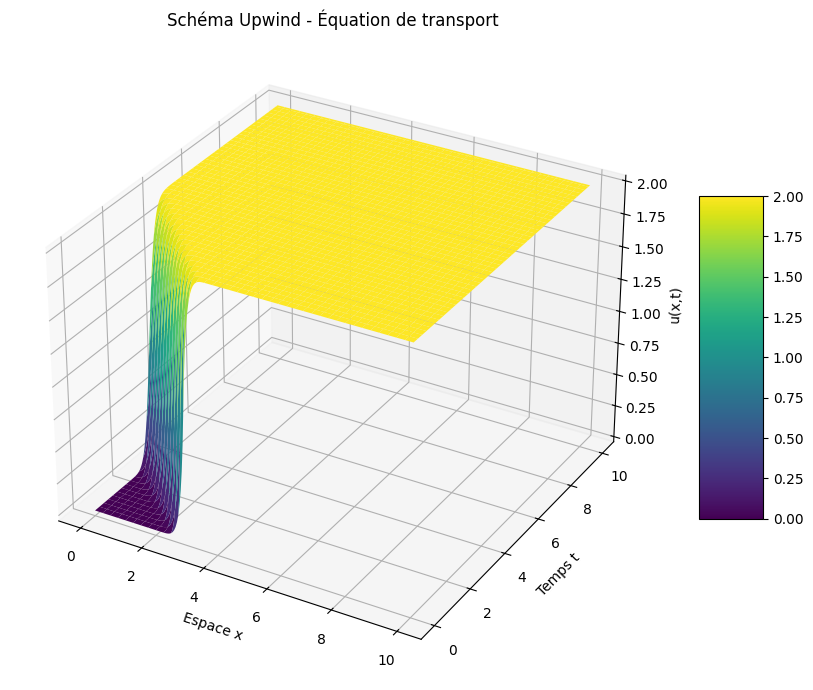

In [6]:
T_bis, X_bis, solution_bis = SchemaUpwind(-1,10,10,u0sigmoid,200,400)


TT_bis, XX_bis = np.meshgrid(T_bis, X_bis)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
surf_bis = ax.plot_surface(XX_bis, TT_bis, solution_bis, cmap='viridis')

ax.set_xlabel('Espace x')
ax.set_ylabel('Temps t')
ax.set_zlabel('u(x,t)')
ax.set_title('Schéma Upwind - Équation de transport')
fig.colorbar(surf_bis, shrink=0.5, aspect=5)

plt.tight_layout()
plt.show()

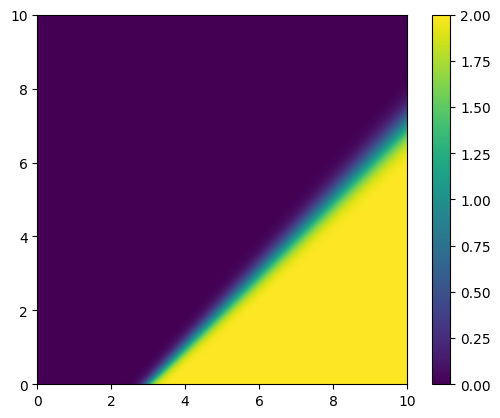

In [7]:
plt.imshow(solution.T,cmap='viridis',origin='lower',extent=[0,10,0,10])
plt.colorbar()

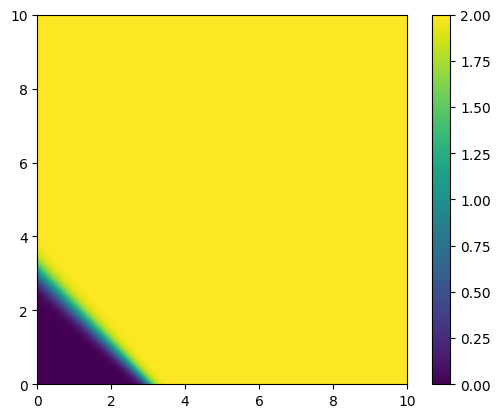

In [8]:
plt.imshow(solution_bis.T,cmap='viridis',origin='lower',extent=[0,10,0,10])
plt.colorbar()

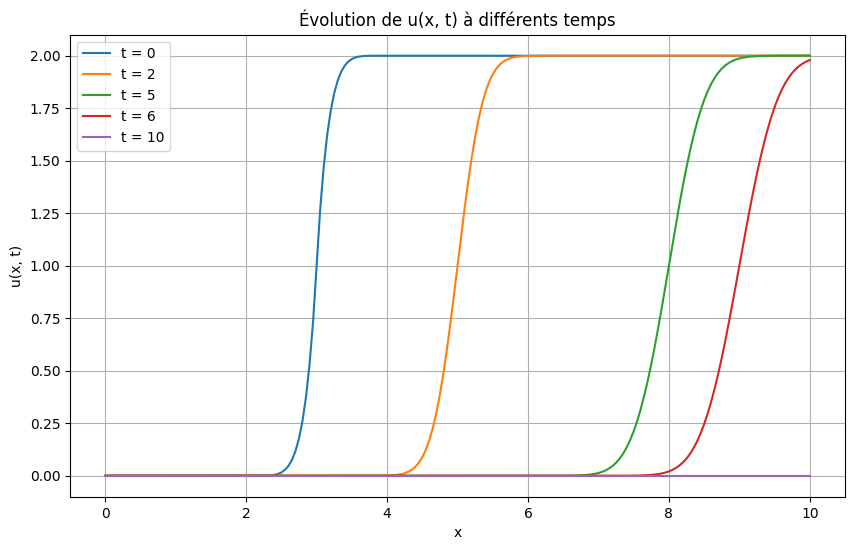

In [9]:
dt = T[1] - T[0]
t_indices = {
    't = 0': 0,
    't = 2': int(2 / dt),
    't = 5': int(5 / dt),
    't = 6': int(6 / dt),
    't = 10': int(10 / dt)
}

plt.figure(figsize=(10, 6))
for label, idx in t_indices.items():
    plt.plot(X, solution[:, idx], label=label)

plt.xlabel("x")
plt.ylabel("u(x, t)")
plt.title("Évolution de u(x, t) à différents temps")
plt.legend()
plt.grid(True)
plt.show()

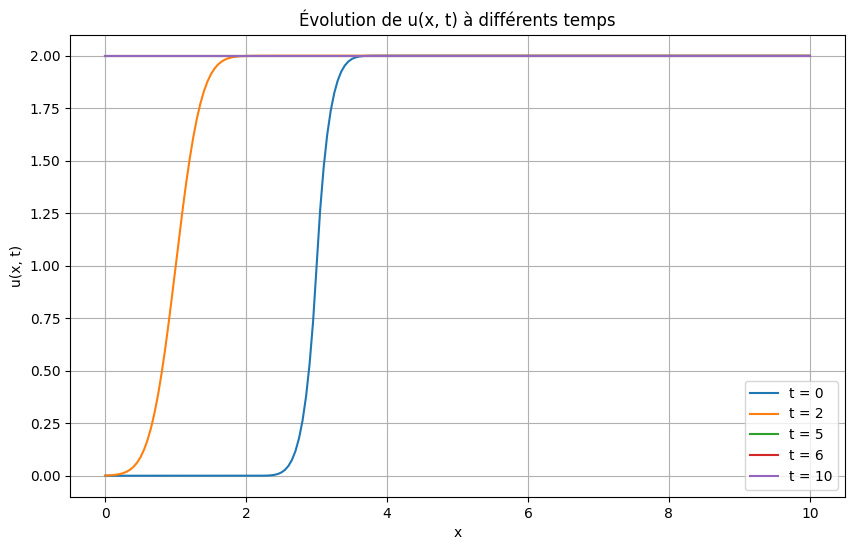

In [10]:
dt = T[1] - T[0]
t_indices = {
    't = 0': 0,
    't = 2': int(2 / dt),
    't = 5': int(5 / dt),
    't = 6': int(6 / dt),
    't = 10': int(10 / dt)
}

plt.figure(figsize=(10, 6))
for label, idx in t_indices.items():
    plt.plot(X, solution_bis[:, idx], label=label)

plt.xlabel("x")
plt.ylabel("u(x, t)")
plt.title("Évolution de u(x, t) à différents temps")
plt.legend()
plt.grid(True)
plt.show()

CFL condition = 0.5


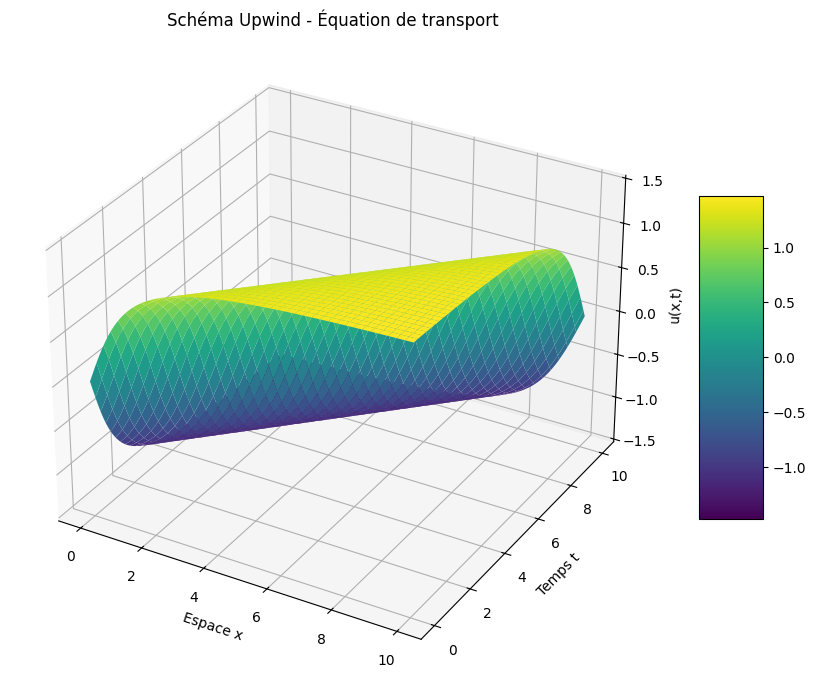

In [11]:
T1, X1, solution1 = SchemaUpwind(1,10,10,np.arctan,200,400)


TT1, XX1 = np.meshgrid(T1, X1)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
surf1 = ax.plot_surface(XX1, TT1, solution1, cmap='viridis')

ax.set_xlabel('Espace x')
ax.set_ylabel('Temps t')
ax.set_zlabel('u(x,t)')
ax.set_title('Schéma Upwind - Équation de transport')
fig.colorbar(surf1, shrink=0.5, aspect=5)

plt.tight_layout()
plt.show()

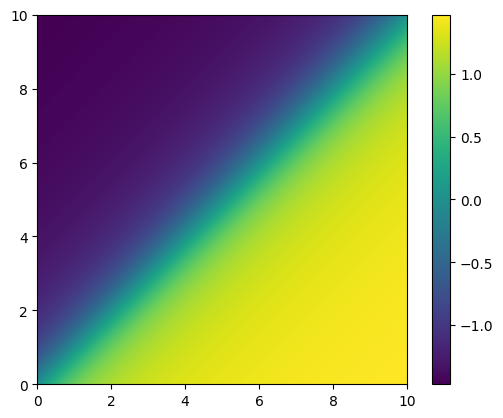

In [12]:
plt.imshow(solution1.T,cmap='viridis',origin='lower',extent=[0,10,0,10])
plt.colorbar()

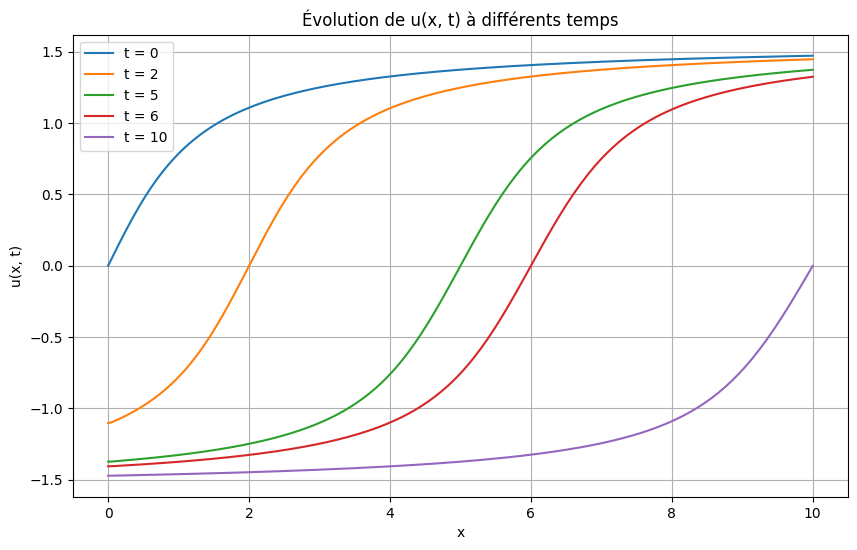

In [13]:
dt = T[1] - T[0]
t_indices = {
    't = 0': 0,
    't = 2': int(2 / dt),
    't = 5': int(5 / dt),
    't = 6': int(6 / dt),
    't = 10': int(10 / dt)
}

plt.figure(figsize=(10, 6))
for label, idx in t_indices.items():
    plt.plot(X, solution1[:, idx], label=label)

plt.xlabel("x")
plt.ylabel("u(x, t)")
plt.title("Évolution de u(x, t) à différents temps")
plt.legend()
plt.grid(True)
plt.show()

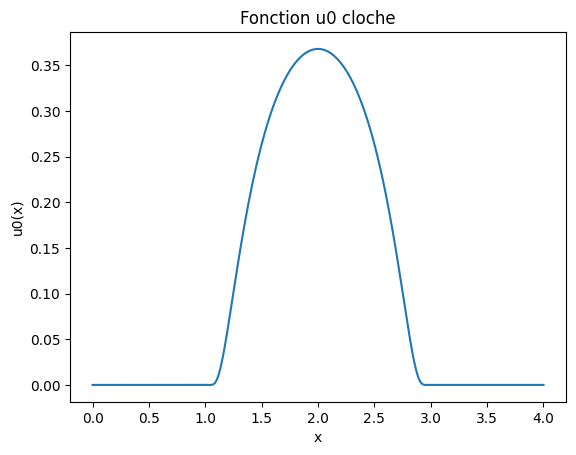

In [14]:
def cloche(x):
    f = np.zeros_like(x)
    mask = (x>1) & (x<3)
    f[mask]=np.exp(-1/(1-(x[mask]-2)**2))
    return f

Ldown = 0
Lup = 4
Nx = 500 

x = np.linspace(Ldown, Lup, Nx)
y = cloche(x)

plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("u0(x)")
plt.title("Fonction u0 cloche")
plt.show()

In [15]:
def SchemaUpwindPeriod(c,tmax,L,u0,M,N):
    U = np.zeros((M+1,N+1))
    T = np.linspace(0,tmax,N+1)
    X = np.linspace(0,L,M+1)
    DeltaT = tmax/N
    DeltaX = L/M
    r = c*DeltaT/DeltaX
    u = u0(X)
    U[:,0]=u
    u = U[0:-1,0]
    if c>0:
        for i in range (N):
            u = (1-r)*u + r*np.roll(u,1)
            U[0:-1,i+1]=u
            U[-1,i+1]=u[0]
    elif c<0:
        for i in range (N):
            u = (1+r)*u - r*np.roll(u,-1)
            U[0:-1,i+1]=u
            U[-1,i+1]=u[0]
    return T, X, U

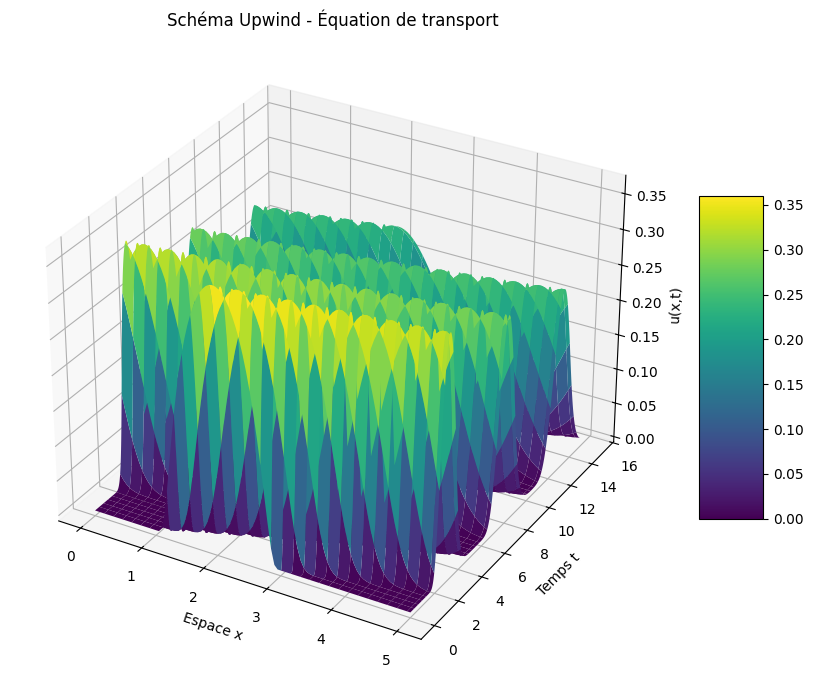

In [16]:
T2, X2, solution2 = SchemaUpwindPeriod(1,15,5,cloche,100,600)


TT2, XX2 = np.meshgrid(T2, X2)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
surf2 = ax.plot_surface(XX2, TT2, solution2, cmap='viridis')

ax.set_xlabel('Espace x')
ax.set_ylabel('Temps t')
ax.set_zlabel('u(x,t)')
ax.set_title('Schéma Upwind - Équation de transport')
fig.colorbar(surf2, shrink=0.5, aspect=5)

plt.tight_layout()
plt.show()

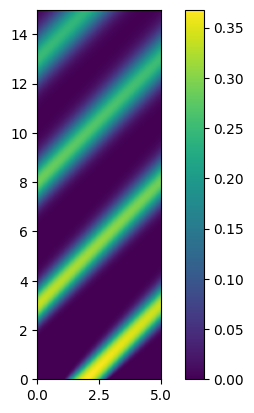

In [17]:
plt.imshow(solution2.T,cmap='viridis',origin='lower',extent=[0,5,0,15])
plt.colorbar()

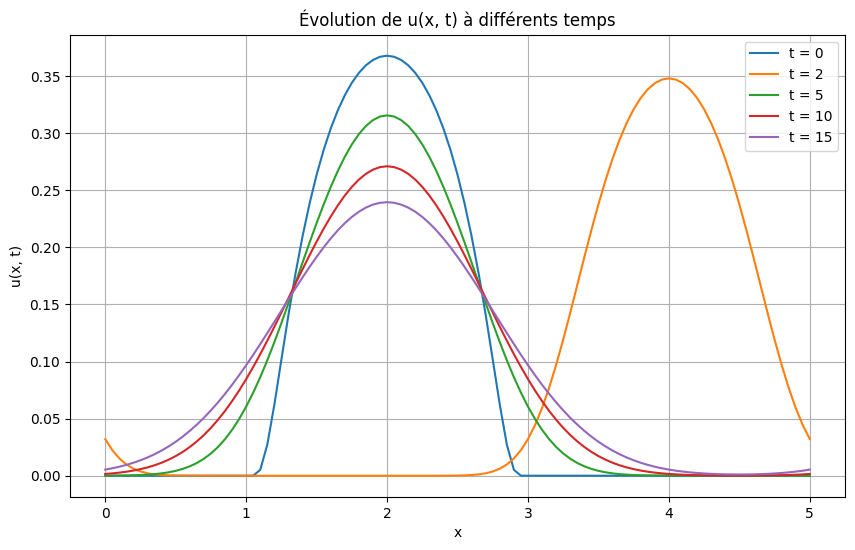

In [18]:
dt = T2[1] - T2[0]
solution_exa = cloche(X2)

t_indices = {
    't = 0': 0,
    't = 2':int(2 / dt) ,
    't = 5': int(5 / dt),
    't = 10': int(10 / dt),
    't = 15': int(15 / dt)
}

plt.figure(figsize=(10, 6))
for label, idx in t_indices.items():
    plt.plot(X2, solution2[:, idx], label=label)

plt.xlabel("x")
plt.ylabel("u(x, t)")
plt.title("Évolution de u(x, t) à différents temps")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
def SchemaUpwindPeriodCorrige(c,tmax,L,u0,M,N):
    U = np.zeros((M+1,N+1))
    T = np.linspace(0,tmax,N+1)
    X = np.linspace(0,L,M+1)
    DeltaT = tmax/N
    DeltaX = L/M
    r = c*DeltaT/DeltaX
    u = u0(X)
    U[:,0]=u
    u = U[0:-1,0]
    if c>0:
        for i in range (N):
            u = (1-r)*u + r*np.roll(u,1) + r*(r-1)/2 * (np.roll(u,-1)-2*u + np.roll(u,1))
            U[0:-1,i+1]=u
            U[-1,i+1]=u[0]
    elif c<0:
        for i in range (N):
            u = (1+r)*u - r*np.roll(u,-1)+ r*(r-1)/2 * (np.roll(u,-1)-2*u + np.roll(u,1))
            U[0:-1,i+1]=u
            U[-1,i+1]=u[0]
    return T, X, U

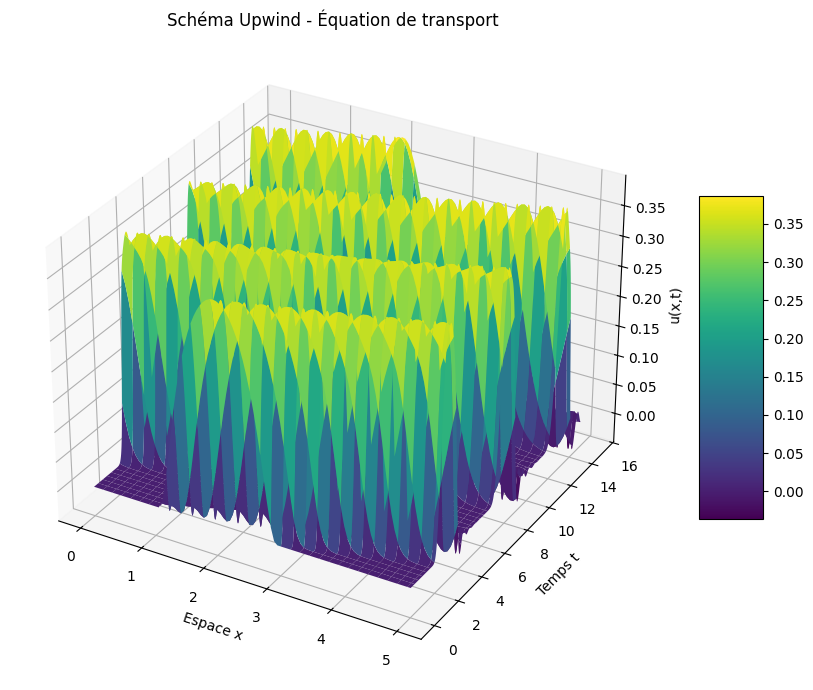

In [20]:
T3, X3, solution3 = SchemaUpwindPeriodCorrige(1,15,5,cloche,100,600)


TT3, XX3 = np.meshgrid(T3, X3)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
surf3 = ax.plot_surface(XX3, TT3, solution3, cmap='viridis')

ax.set_xlabel('Espace x')
ax.set_ylabel('Temps t')
ax.set_zlabel('u(x,t)')
ax.set_title('Schéma Upwind - Équation de transport')
fig.colorbar(surf3, shrink=0.5, aspect=5)

plt.tight_layout()
plt.show()

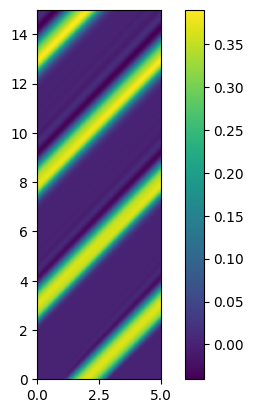

In [21]:
plt.imshow(solution3.T,cmap='viridis',origin='lower',extent=[0,5,0,15])
plt.colorbar()

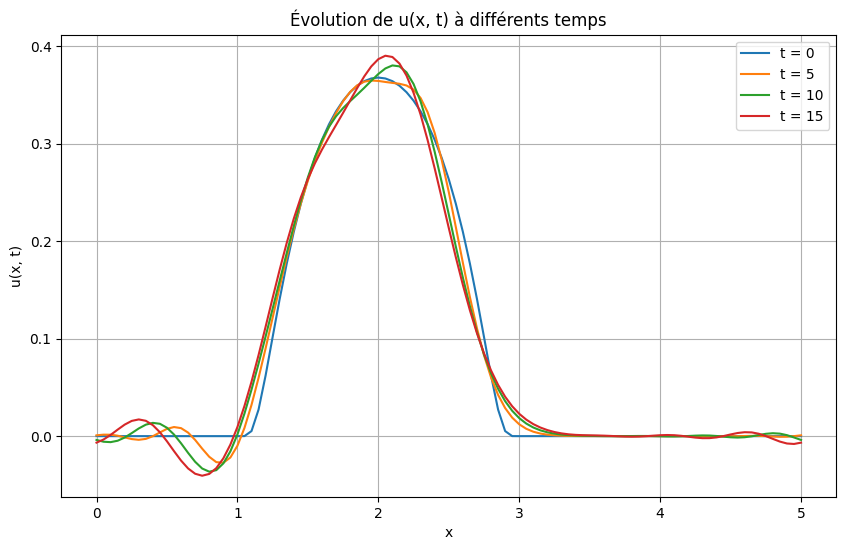

In [22]:
dt = T3[1] - T3[0]

t_indices = {
    't = 0': 0,
    't = 5': int(5 / dt),
    't = 10': int(10 / dt),
    't = 15': int(15 / dt)
}

plt.figure(figsize=(10, 6))
for label, idx in t_indices.items():
    plt.plot(X3, solution3[:, idx], label=label)

plt.xlabel("x")
plt.ylabel("u(x, t)")
plt.title("Évolution de u(x, t) à différents temps")
plt.legend()
plt.grid(True)
plt.show()